Wrote 4320 rows to car_data_raw.csv
Shape: (4320, 8)
<class 'pandas.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4299 non-null   str    
 1   year           4320 non-null   int64  
 2   selling_price  4231 non-null   float64
 3   km_driven      4191 non-null   float64
 4   fuel           4254 non-null   str    
 5   seller_type    4320 non-null   str    
 6   transmission   4320 non-null   str    
 7   owner          4276 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 459.2 KB
Missing values per column:
 name              21
year               0
selling_price     89
km_driven        129
fuel              66
seller_type        0
transmission       0
owner             44
dtype: int64

Duplicate rows: 120

Raw unique fuel values (note the inconsistency): <ArrowStringArray>
[         nan,     'PETROL',     'Petrol',     'Diese

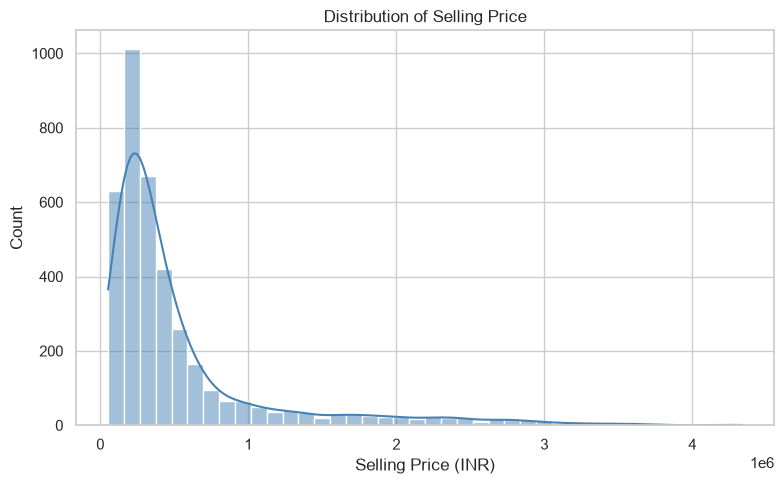

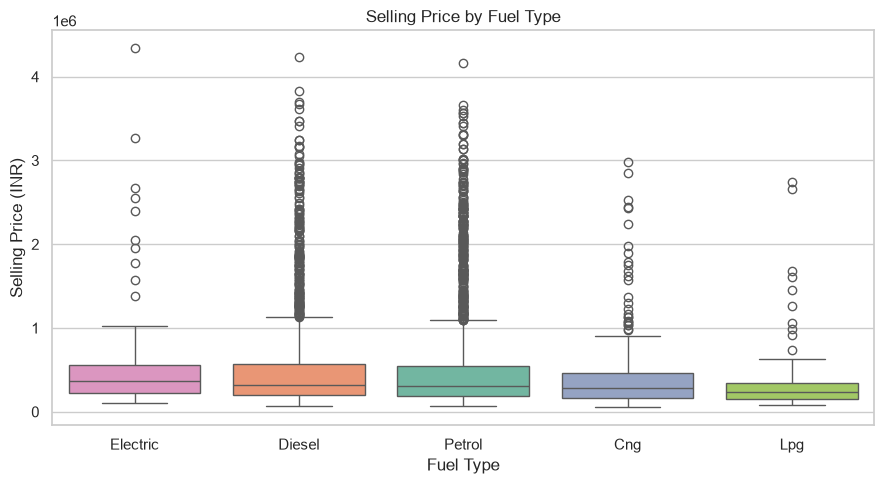

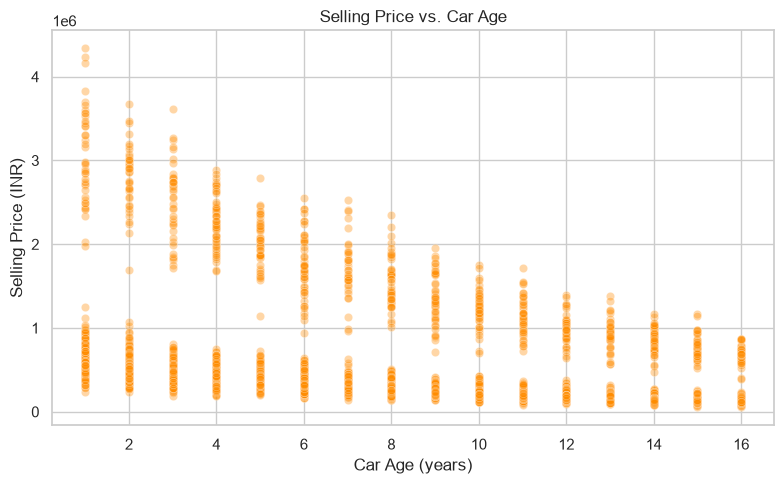

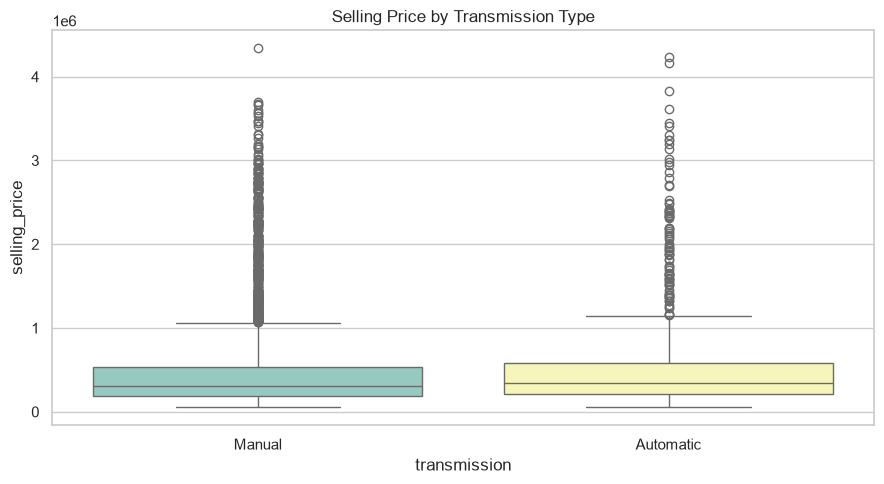

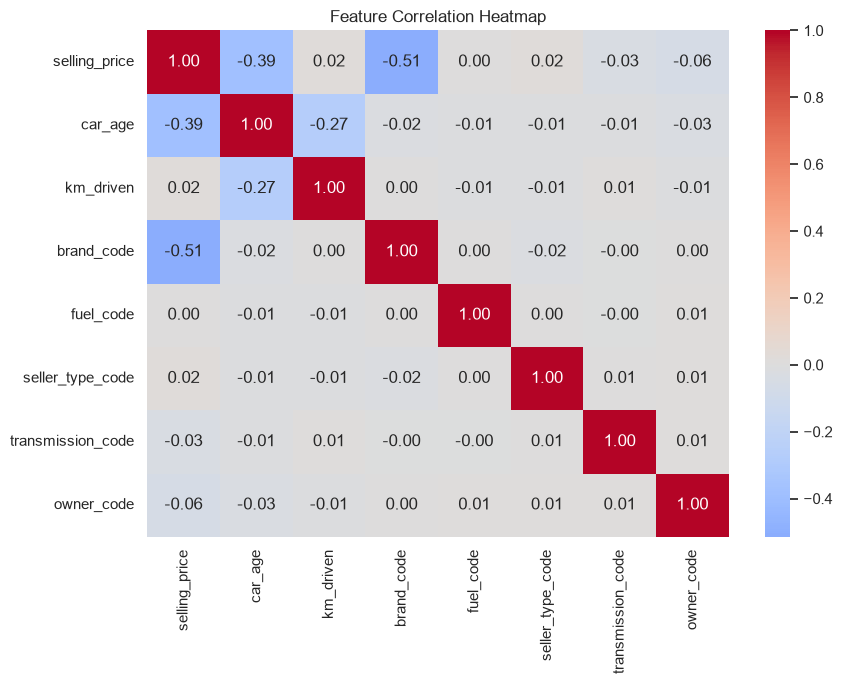

Train shape: (3099, 7)  Test shape: (775, 7)
Trained: Linear Regression
Trained: Random Forest
Trained: Gradient Boosting


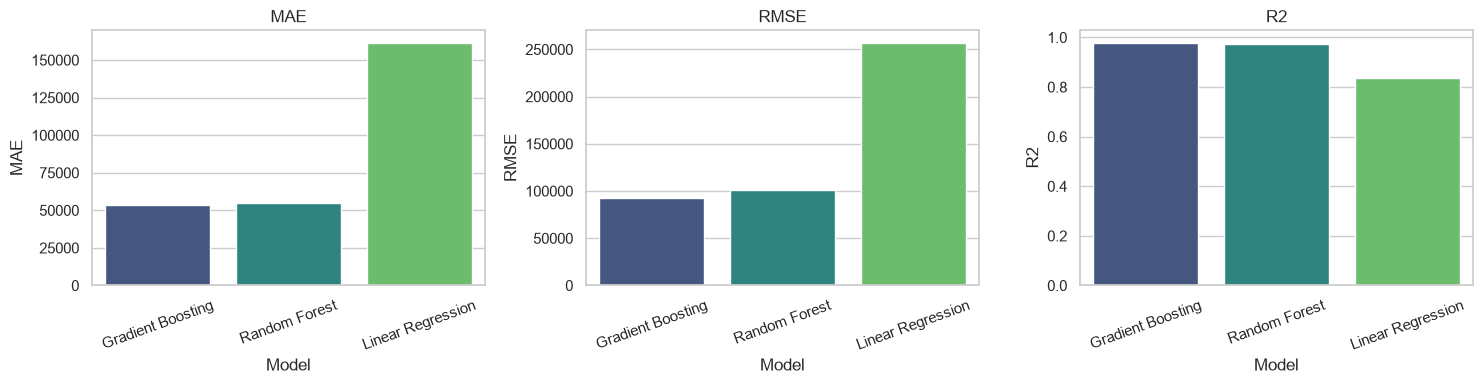

Best performing model: Gradient Boosting
Model    Gradient Boosting
MAE           53410.016392
RMSE          92205.071779
R2                0.978929
Name: 0, dtype: object


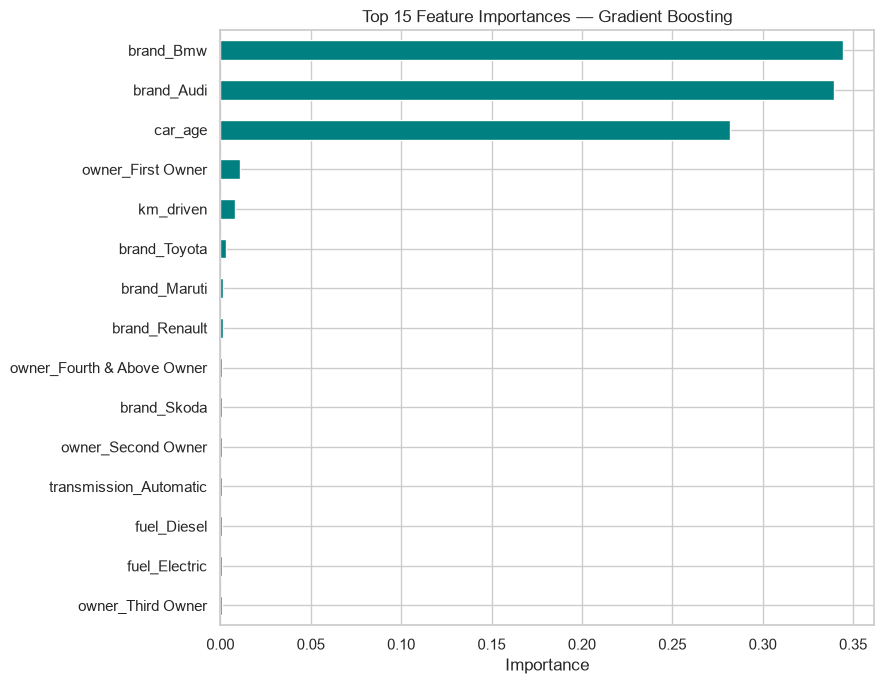

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = "car_data_raw.csv"   # <-- point this at the real Kaggle CSV if you have it
RANDOM_STATE = 42


# ===== 1. Download / Source the Dataset =====
# --- Synthetic CarDekho-style dataset generator (skip this cell if using the real Kaggle CSV) ---
rng = np.random.default_rng(RANDOM_STATE)

CAR_CATALOG = {
    "Maruti": ["Swift", "Baleno", "Alto", "Dzire", "Wagon R", "Ertiga", "Vitara Brezza"],
    "Hyundai": ["i20", "Creta", "Grand i10", "Verna", "Venue", "Santro"],
    "Honda": ["City", "Amaze", "Jazz", "WR-V", "Civic"],
    "Toyota": ["Innova", "Fortuner", "Etios", "Corolla", "Glanza"],
    "Ford": ["EcoSport", "Figo", "Endeavour", "Aspire"],
    "Tata": ["Nexon", "Tiago", "Altroz", "Harrier", "Safari"],
    "Mahindra": ["XUV500", "Scorpio", "Bolero", "XUV300"],
    "Renault": ["Kwid", "Duster", "Triber"],
    "Volkswagen": ["Polo", "Vento", "Ameo"],
    "Skoda": ["Rapid", "Octavia", "Superb"],
    "BMW": ["3 Series", "5 Series", "X1"],
    "Audi": ["A4", "A6", "Q3"],
}
BRAND_BASE_PRICE = {
    "Maruti": 6, "Hyundai": 7, "Honda": 8, "Toyota": 11, "Ford": 8,
    "Tata": 7, "Mahindra": 9, "Renault": 6, "Volkswagen": 8, "Skoda": 10,
    "BMW": 40, "Audi": 45,
}
FUEL_TYPES = ["Petrol", "Diesel", "CNG", "LPG", "Electric"]
FUEL_WEIGHTS = [0.52, 0.38, 0.06, 0.02, 0.02]
SELLER_TYPES = ["Dealer", "Individual", "Trustmark Dealer"]
TRANSMISSIONS = ["Manual", "Automatic"]
OWNERS = ["First Owner", "Second Owner", "Third Owner", "Fourth & Above Owner"]
OWNER_WEIGHTS = [0.55, 0.28, 0.12, 0.05]

N = 4200
rows = []
for _ in range(N):
    brand = rng.choice(list(CAR_CATALOG.keys()))
    model = rng.choice(CAR_CATALOG[brand])
    year = int(rng.integers(2005, 2021))
    age = 2021 - year
    km_driven = int(max(500, rng.normal(70000 - age * 1500, 25000)))
    fuel = rng.choice(FUEL_TYPES, p=FUEL_WEIGHTS)
    seller_type = rng.choice(SELLER_TYPES, p=[0.55, 0.4, 0.05])
    transmission = rng.choice(TRANSMISSIONS, p=[0.82, 0.18])
    owner = rng.choice(OWNERS, p=OWNER_WEIGHTS)

    base_lakh = BRAND_BASE_PRICE[brand]
    depreciation = 0.90 ** age
    km_penalty = max(0.5, 1 - km_driven / 400000)
    fuel_mult = {"Diesel": 1.08, "Petrol": 1.0, "CNG": 0.9, "LPG": 0.85, "Electric": 1.3}[fuel]
    trans_mult = 1.15 if transmission == "Automatic" else 1.0
    owner_mult = {"First Owner": 1.0, "Second Owner": 0.88, "Third Owner": 0.78, "Fourth & Above Owner": 0.65}[owner]
    noise = rng.normal(1.0, 0.08)

    selling_price_lakh = base_lakh * depreciation * km_penalty * fuel_mult * trans_mult * owner_mult * noise
    selling_price = max(20000, round(selling_price_lakh * 100000, -3))

    rows.append({
        "name": f"{brand} {model}", "year": year, "selling_price": selling_price,
        "km_driven": km_driven, "fuel": fuel, "seller_type": seller_type,
        "transmission": transmission, "owner": owner,
    })

df_gen = pd.DataFrame(rows)

def messy_case(val, rng_local):
    r = rng_local.random()
    if r < 0.15: return val.lower()
    if r < 0.25: return val.upper()
    if r < 0.32: return f" {val} "
    return val

for col in ["fuel", "transmission", "seller_type"]:
    df_gen[col] = df_gen[col].apply(lambda v: messy_case(v, rng))

for col, frac in [("selling_price", 0.02), ("km_driven", 0.03), ("fuel", 0.015), ("owner", 0.01), ("name", 0.005)]:
    idx = rng.choice(df_gen.index, size=int(len(df_gen) * frac), replace=False)
    df_gen.loc[idx, col] = np.nan

dupe_idx = rng.choice(df_gen.index, size=120, replace=False)
df_gen = pd.concat([df_gen, df_gen.loc[dupe_idx]], ignore_index=True)
df_gen = df_gen.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

df_gen.to_csv(DATA_PATH, index=False)
print(f"Wrote {len(df_gen)} rows to {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

df.info()


# ===== 2. Data Cleaning =====
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nRaw unique fuel values (note the inconsistency):", df["fuel"].unique())

# Standardize categorical text: strip whitespace, fix casing (e.g. "petrol" / "PETROL " -> "Petrol")
categorical_text_cols = ["fuel", "seller_type", "transmission", "owner", "name"]
for col in categorical_text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()
    df.loc[df[col].isin(["Nan", "None"]), col] = np.nan  # restore true NaNs lost to str conversion

print("Cleaned unique fuel values:", df["fuel"].dropna().unique())

# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows -> {len(df)} remaining")

# Drop rows missing critical fields (target or key identifying features)
before = len(df)
df = df.dropna(subset=["selling_price", "km_driven", "fuel", "name", "owner"])
print(f"Dropped {before - len(df)} rows with missing critical values -> {len(df)} remaining")

df["km_driven"] = df["km_driven"].astype(int)
df["selling_price"] = df["selling_price"].astype(int)


# ===== 3. Feature Engineering =====
CURRENT_YEAR = 2021  # dataset reference year; use current calendar year for real-world data

df["car_age"] = CURRENT_YEAR - df["year"]
df = df[df["car_age"] >= 0]  # guard against bad year values

df["brand"] = df["name"].str.split().str[0].str.title()

df[["name", "brand", "year", "car_age"]].head()

print("Top brands by listing count:")
df["brand"].value_counts().head(10)


# ===== 4. Exploratory Data Analysis (EDA) =====
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["selling_price"], bins=40, kde=True, ax=ax, color="steelblue")
ax.set_title("Distribution of Selling Price")
ax.set_xlabel("Selling Price (INR)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
order = df.groupby("fuel")["selling_price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="fuel", y="selling_price", order=order, hue="fuel", legend=False, ax=ax, palette="Set2")
ax.set_title("Selling Price by Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Selling Price (INR)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="car_age", y="selling_price", alpha=0.35, ax=ax, color="darkorange")
ax.set_title("Selling Price vs. Car Age")
ax.set_xlabel("Car Age (years)")
ax.set_ylabel("Selling Price (INR)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="transmission", y="selling_price", hue="transmission", legend=False, ax=ax, palette="Set3")
ax.set_title("Selling Price by Transmission Type")
plt.tight_layout()
plt.show()


# ===== 5. Encode Categorical Variables =====
features = ["brand", "car_age", "km_driven", "fuel", "seller_type", "transmission", "owner"]
target = "selling_price"

X = df[features].copy()
y = df[target].copy()

categorical_cols = ["brand", "fuel", "seller_type", "transmission", "owner"]
numeric_cols = ["car_age", "km_driven"]

# Quick label-encoded view purely for the correlation heatmap below
df_encoded_view = df[numeric_cols + ["selling_price"]].copy()
for col in categorical_cols:
    df_encoded_view[col + "_code"] = df[col].astype("category").cat.codes

df_encoded_view.head()


# ===== 6. Feature Correlation Heatmap =====
corr_cols = ["selling_price", "car_age", "km_driven"] + [c + "_code" for c in categorical_cols]
corr = df_encoded_view[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


# ===== `car_age` shows a clear negative correlation with `selling_price` (older cars sell for less), which matches the scatter plot above. The label-encoded categorical codes correlate weakly with price individually — that's expected, since one-hot encoding (used for actual modeling) captures per-category effects that a single ordinal code cannot. =====

# ===== 7. Train / Test Split =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


# ===== 8. Model Training =====
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)],
    remainder="passthrough",  # numeric_cols pass through unchanged
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

fitted_pipelines = {}
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    print(f"Trained: {name}")


# ===== 9. Model Evaluation — MAE, RMSE, R² =====
results = []
for name, pipe in fitted_pipelines.items():
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    sns.barplot(data=results_df, x="Model", y=metric, hue="Model", legend=False, ax=ax, palette="viridis")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]
print(f"Best performing model: {best_model_name}")
print(results_df.iloc[0])


# ===== 10. Feature Importance (Best Model) =====
model_step = best_pipeline.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    ohe = best_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
    ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
    all_feature_names = list(ohe_feature_names) + numeric_cols

    importances = pd.Series(model_step.feature_importances_, index=all_feature_names)
    top_importances = importances.sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(9, 7))
    top_importances.sort_values().plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Top 15 Feature Importances — {best_model_name}")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()
elif hasattr(model_step, "coef_"):
    ohe = best_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
    ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
    all_feature_names = list(ohe_feature_names) + numeric_cols

    coefs = pd.Series(model_step.coef_, index=all_feature_names)
    top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).head(15).index)

    fig, ax = plt.subplots(figsize=(9, 7))
    top_coefs.sort_values().plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Top 15 Coefficients (by magnitude) — {best_model_name}")
    plt.tight_layout()
    plt.show()
